# 지하철 이용승객 분석 과제

### 1개월 데이터 6개 합치기 

In [229]:
import pandas as pd

In [230]:
#6개의 파일 불러와서 합치기

raw = pd.DataFrame()
raw.head()

file1 = r'./rawfiles/CARD_SUBWAY_MONTH_201901.csv'
file2 = r'./rawfiles/CARD_SUBWAY_MONTH_201902.csv'
file3 = r'./rawfiles/CARD_SUBWAY_MONTH_201903.csv'
file4 = r'./rawfiles/CARD_SUBWAY_MONTH_201904.csv'
file5 = r'./rawfiles/CARD_SUBWAY_MONTH_201905.csv'
file6 = r'./rawfiles/CARD_SUBWAY_MONTH_201906.csv'

temp1 = pd.read_csv(file1)
temp2 = pd.read_csv(file2)
temp3 = pd.read_csv(file3)
temp4 = pd.read_csv(file4)
temp5 = pd.read_csv(file5)
temp6 = pd.read_csv(file6)

raw = pd.concat([temp1, temp2, temp3, temp4, temp5, temp6], axis=0, ignore_index=True)

In [231]:
# 결과 확인
raw

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20190101,2호선,을지로4가,3862.0,3728.0,20190104
1,20190101,3호선,을지로3가,8104.0,7554.0,20190104
2,20190101,2호선,을지로입구,22478.0,21330.0,20190104
3,20190101,2호선,시청,8381.0,6049.0,20190104
4,20190101,6호선,동묘앞,8045.0,8504.0,20190104
...,...,...,...,...,...,...
107023,20190630,7호선,마들,6622.0,6116.0,20190703
107024,20190630,4호선,노원,14071.0,14702.0,20190703
107025,20190630,7호선,중계,9516.0,8981.0,20190703
107026,20190630,7호선,하계,11645.0,11121.0,20190703


### 요일, 연월, 월일 컬럼 추가

In [233]:
# '사용일자' 타입 int64 --> DateTime 타입으로 변경 : pandas.to_datetime 사용

raw['사용일자'] = pd.to_datetime(raw['사용일자'], format='%Y%m%d')
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107028 entries, 0 to 107027
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   사용일자    107028 non-null  datetime64[ns]
 1   노선명     107028 non-null  object        
 2   역명      107028 non-null  object        
 3   승차총승객수  107028 non-null  float64       
 4   하차총승객수  107028 non-null  float64       
 5   등록일자    107028 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 4.9+ MB


In [234]:
# 사용일자에 대해서 요일로 변환
raw['요일'] = raw['사용일자'].dt.dayofweek
raw.tail()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,요일
107023,2019-06-30,7호선,마들,6622.0,6116.0,20190703,6
107024,2019-06-30,4호선,노원,14071.0,14702.0,20190703,6
107025,2019-06-30,7호선,중계,9516.0,8981.0,20190703,6
107026,2019-06-30,7호선,하계,11645.0,11121.0,20190703,6
107027,2019-06-30,6호선,태릉입구,5730.0,5214.0,20190703,6


In [235]:
conv = {
    0 : '일',
    1 : '월',
    2 : '화',
    3 : '수',
    4 : '목',
    5 : '금',
    6 : '토'
}

# 숫자 요일을 한글명 요일로 변경
raw['요일'] = raw['요일'].map(conv)

In [236]:
raw.sample(5)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,요일
67189,2019-04-24,경강선,이천,2731.0,2941.0,20190427,화
68472,2019-04-26,2호선,신도림,4260.0,4407.0,20190429,목
3325,2019-01-06,경강선,여주,1698.0,1656.0,20190109,토
20254,2019-02-04,5호선,청구,1286.0,1378.0,20190207,일
17682,2019-01-30,9호선,마곡나루,10880.0,10443.0,20190202,화


In [237]:
# pandas.Series.dt.strftime 활용
raw['사용일자'].dt.strftime('%Y-%m')

# 사용일자 컬럼에서 년월 값을 가져와 년월 컬럼 만들기
raw['연월'] = raw['사용일자'].dt.strftime('%Y-%m')
raw.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,요일,연월
0,2019-01-01,2호선,을지로4가,3862.0,3728.0,20190104,월,2019-01
1,2019-01-01,3호선,을지로3가,8104.0,7554.0,20190104,월,2019-01
2,2019-01-01,2호선,을지로입구,22478.0,21330.0,20190104,월,2019-01
3,2019-01-01,2호선,시청,8381.0,6049.0,20190104,월,2019-01
4,2019-01-01,6호선,동묘앞,8045.0,8504.0,20190104,월,2019-01


In [238]:
# pandas.Series.dt.strftime 활용
raw['사용일자'].dt.strftime('%m-%d')

# 사용일자 컬럼에서 월일 값을 가져와 월일 컬럼 만들기
raw['월일'] = raw['사용일자'].dt.strftime('%m-%d')
raw.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,요일,연월,월일
0,2019-01-01,2호선,을지로4가,3862.0,3728.0,20190104,월,2019-01,01-01
1,2019-01-01,3호선,을지로3가,8104.0,7554.0,20190104,월,2019-01,01-01
2,2019-01-01,2호선,을지로입구,22478.0,21330.0,20190104,월,2019-01,01-01
3,2019-01-01,2호선,시청,8381.0,6049.0,20190104,월,2019-01,01-01
4,2019-01-01,6호선,동묘앞,8045.0,8504.0,20190104,월,2019-01,01-01


## Q1) 2019.01~06중에 언제 지하철을 가장 많이 이용했을까?

In [240]:
# 승차총승객수와 하차총승객수를 더해서 승하자총승객수 열을 생성
raw['승하자총승객수'] = raw['승차총승객수'] + raw['하차총승객수']

# 직접 그룹화 
monthly_usage = raw.groupby('연월')['승하자총승객수'].sum().reset_index()
print(monthly_usage)

# 승객이 가장 많은 월 및 승객 수
max_usage_month = monthly_usage.loc[monthly_usage['승하자총승객수'].idxmax(), '연월']  # 승객이 가장 많은 월
max_usage_value = monthly_usage['승하자총승객수'].max()  # 그 월의 승객 수

print(f"가장 많이 이용한 달: {max_usage_month}, 총 승객 수: {max_usage_value}")

        연월      승하자총승객수
0  2019-01  442746389.0
1  2019-02  379836010.0
2  2019-03  466692826.0
3  2019-04  470934348.0
4  2019-05  485718557.0
5  2019-06  442210635.0
가장 많이 이용한 달: 2019-05, 총 승객 수: 485718557.0


## Q2) 가설 - 1월~6월 중에 5월에 지하철 승객 수가 많다? 

In [242]:
# 5월의 승하차 총 승객 수 추출
may_usage = monthly_usage[monthly_usage['연월'] == '2019-05']['승하자총승객수'].values[0]

# 5월을 제외한 나머지 월의 승객 수를 추출
other_months_usage = monthly_usage[monthly_usage['연월'] != '2019-05']

# 5월과 다른 월의 승객 수 비교
is_may_highest = may_usage > other_months_usage['승하자총승객수'].max()

# 결과 출력
if is_may_highest:
    print(f"가설을 증명합니다: 5월의 승객 수 ({may_usage})가 다른 월보다 많습니다.")
else:
    print(f"가설을 부정합니다: 5월의 승객 수 ({may_usage})가 다른 월보다 많지 않습니다.")

가설을 증명합니다: 5월의 승객 수 (485718557.0)가 다른 월보다 많습니다.


In [243]:
# 5월의 승하차 총 승객 수 추출
may_usage = monthly_usage[monthly_usage['연월'] == '2019-05']['승하자총승객수'].values[0]

# 비교 결과를 저장할 리스트
comparison_results = []

# 1월부터 4월, 6월까지 비교
for month in monthly_usage['연월']:
    if month != '2019-05':
        usage = monthly_usage[monthly_usage['연월'] == month]['승하자총승객수'].values[0]
        if may_usage > usage:
            comparison_results.append(f"5월의 승객 수 ({may_usage})가 {month}의 승객 수 ({usage})보다 많습니다.")
        else:
            comparison_results.append(f"5월의 승객 수 ({may_usage})가 {month}의 승객 수 ({usage})보다 많지 않습니다.")

# 비교 결과 출력
for result in comparison_results:
    print(result)

# 결론 도출
is_may_highest = True  # 가정: 5월의 승객 수가 가장 많다고 시작

for month in monthly_usage['연월']:
    if month != '2019-05':
        usage = monthly_usage[monthly_usage['연월'] == month]['승하자총승객수'].values[0]
        if may_usage <= usage:  # 만약 5월의 승객 수가 다른 월의 승객 수보다 작거나 같다면
            is_may_highest = False
            break

if is_may_highest:
    print("결론: 5월의 승객 수가 다른 월보다 많습니다.")
else:
    print("결론: 5월의 승객 수가 다른 월보다 많지 않습니다.")


5월의 승객 수 (485718557.0)가 2019-01의 승객 수 (442746389.0)보다 많습니다.
5월의 승객 수 (485718557.0)가 2019-02의 승객 수 (379836010.0)보다 많습니다.
5월의 승객 수 (485718557.0)가 2019-03의 승객 수 (466692826.0)보다 많습니다.
5월의 승객 수 (485718557.0)가 2019-04의 승객 수 (470934348.0)보다 많습니다.
5월의 승객 수 (485718557.0)가 2019-06의 승객 수 (442210635.0)보다 많습니다.
결론: 5월의 승객 수가 다른 월보다 많습니다.


## Q3) 가설 - 요일중에서 목요일에 지하철 승객 수가 많다?

In [245]:
# 요일별 승하차 총 승객 수 계산
weekday_usage = raw.groupby('요일')['승하자총승객수'].sum().reset_index()

# 요일 데이터 출력
print(weekday_usage)

# 목요일의 승객 수 추출
if '목' in weekday_usage['요일'].values:
    thursday_usage = weekday_usage[weekday_usage['요일'] == '목']['승하자총승객수'].values[0]

    # 비교 결과를 저장할 리스트
    comparison_results = []

    # 목요일을 제외한 다른 요일과 비교
    for day in weekday_usage['요일']:
        if day != '목':
            usage = weekday_usage[weekday_usage['요일'] == day]['승하자총승객수'].values[0]
            if thursday_usage > usage:
                comparison_results.append(f"목요일의 승객 수 ({thursday_usage})가 {day}의 승객 수 ({usage})보다 많습니다.")
            else:
                comparison_results.append(f"목요일의 승객 수 ({thursday_usage})가 {day}의 승객 수 ({usage})보다 많지 않습니다.")

    # 비교 결과 출력
    for result in comparison_results:
        print(result)

    # 결론 도출
    is_thursday_highest = True  # 가정: 목요일의 승객 수가 가장 많다고 시작

    for day in weekday_usage['요일']:
        if day != '목':  # 여기를 들여쓰기
            usage = weekday_usage[weekday_usage['요일'] == day]['승하자총승객수'].values[0]
            if thursday_usage <= usage:  # 만약 목요일의 승객 수가 다른 요일의 승객 수보다 작거나 같다면
                is_thursday_highest = False
                break

    if is_thursday_highest:
        print("결론: 목요일의 승객 수가 다른 요일보다 많습니다.")
    else:
        print("결론: 목요일의 승객 수가 다른 요일보다 많지 않습니다.")


  요일      승하자총승객수
0  금  341950018.0
1  목  445310717.0
2  수  428684383.0
3  월  411979965.0
4  일  391555551.0
5  토  247523995.0
6  화  421134136.0
목요일의 승객 수 (445310717.0)가 금의 승객 수 (341950018.0)보다 많습니다.
목요일의 승객 수 (445310717.0)가 수의 승객 수 (428684383.0)보다 많습니다.
목요일의 승객 수 (445310717.0)가 월의 승객 수 (411979965.0)보다 많습니다.
목요일의 승객 수 (445310717.0)가 일의 승객 수 (391555551.0)보다 많습니다.
목요일의 승객 수 (445310717.0)가 토의 승객 수 (247523995.0)보다 많습니다.
목요일의 승객 수 (445310717.0)가 화의 승객 수 (421134136.0)보다 많습니다.
결론: 목요일의 승객 수가 다른 요일보다 많습니다.


## Q4) 연월 각각에 대해 일자별(월일별) 승하차총승객수 그래프 그리기

폰트 이슈 발생... 해결이 안 됨 -> 나중에 다시 할 것...

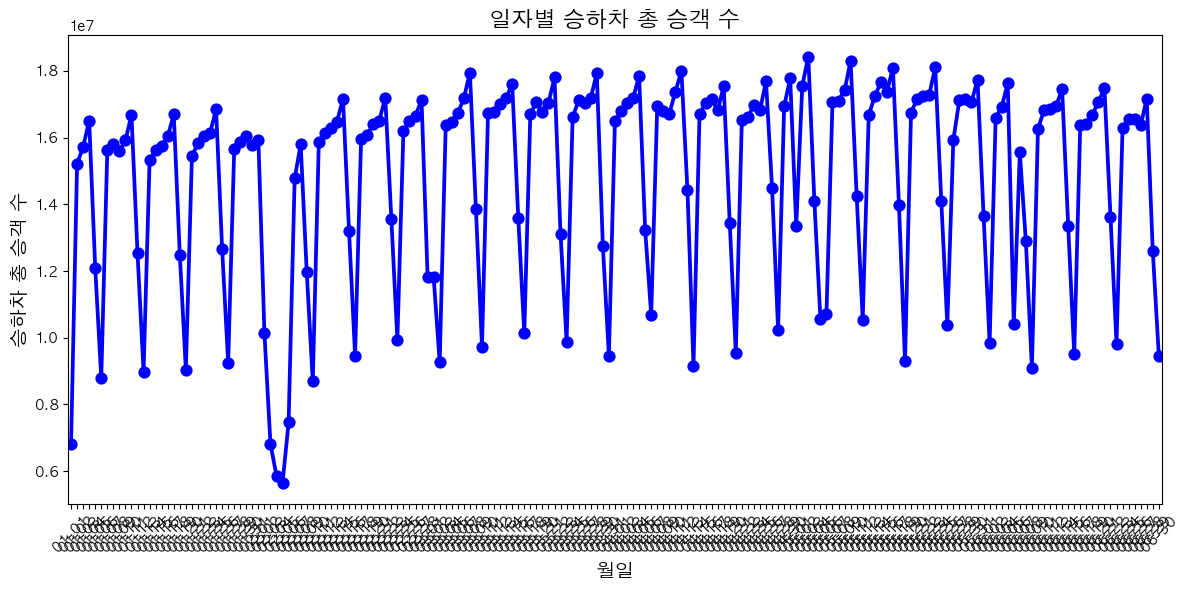

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'

# '월일'과 '승하자총승객수'를 기준으로 일자별로 그룹화하여 승하차 총 승객 수 계산
daily_usage = raw.groupby(['월일'])['승하자총승객수'].sum().reset_index()

# Seaborn의 pointplot을 사용하여 그래프 그리기
plt.figure(figsize=(12, 6))
sns.pointplot(data=daily_usage, x='월일', y='승하자총승객수', marker='o', color='blue')

# 그래프 제목 및 축 레이블 추가
plt.title('일자별 승하차 총 승객 수', fontsize=16)
plt.xlabel('월일', fontsize=14)
plt.ylabel('승하차 총 승객 수', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 표시
plt.show()

## Q5) 가장 승객이 많이 타는 승차역은?

In [250]:
# 승차역별로 그룹화하여 승객 수 합산
boarding_usage = raw.groupby('역명')['승차총승객수'].sum().reset_index()

# 가장 승객이 많이 타는 승차역 찾기
top_boarding_station = boarding_usage.loc[boarding_usage['승차총승객수'].idxmax()]

# 결과 출력
print(f"가장 승객이 많이 타는 승차역: {top_boarding_station['역명']}, 승객 수: {top_boarding_station['승차총승객수']}")

가장 승객이 많이 타는 승차역: 잠실, 승객 수: 18574323.0


In [251]:
# 승차역별로 그룹화하여 승객 수 합산
boarding_usage = raw.groupby('역명')['승차총승객수'].sum().reset_index()

# 가장 승객이 많이 타는 승차역 찾기
top_boarding_station = boarding_usage.loc[boarding_usage['승차총승객수'].idxmax()]

# 결과 출력
print(f"가장 승객이 많이 타는 승차역: {top_boarding_station['역명']}, 승객 수: {top_boarding_station['승차총승객수']}")

# 상위 5개 승차역 출력
top_5_boarding_stations = boarding_usage.nlargest(5, '승차총승객수')

print("\n상위 5개 승차역:")
print(top_5_boarding_stations)


가장 승객이 많이 타는 승차역: 잠실, 승객 수: 18574323.0

상위 5개 승차역:
        역명      승차총승객수
413     잠실  18574323.0
11      강남  18148024.0
33   고속터미널  17541287.0
496   홍대입구  17270084.0
247    서울역  17165598.0


## Q6) 노선별로 역별/요일별 승차승객수를 비교(1~9호선)

여기도 한글 오류랑 가독성 안 좋음 이슈 해결해야함

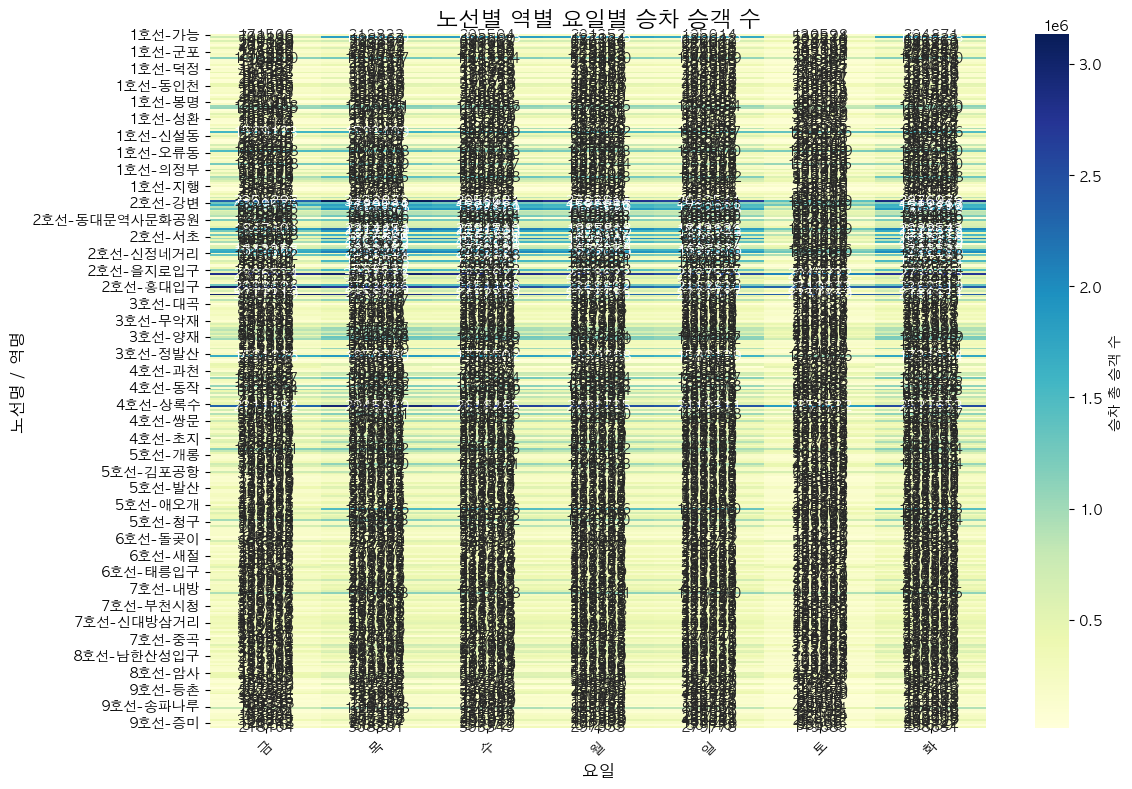

In [254]:
# 노선별, 역별, 요일별 승차 승객 수 집계
heatmap_data = raw[raw['노선명'].isin(['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선'])]
heatmap_data = heatmap_data.groupby(['노선명', '역명', '요일'])['승차총승객수'].sum().unstack().fillna(0)

# 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': '승차 총 승객 수'})

# 그래프 제목 및 레이블 설정
plt.title('노선별 역별 요일별 승차 승객 수', fontsize=16)
plt.xlabel('요일', fontsize=12)
plt.ylabel('노선명 / 역명', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 보여주기
plt.show()

## Q7) 1호선에서 가장 하차를 많이 하는 역은?

In [256]:
# 1호선 데이터 필터링
line_1_data = raw[raw['노선명'] == '1호선']

# 하차역별로 그룹화하여 하차 총 승객 수 합산
alighting_usage = line_1_data.groupby('역명')['하차총승객수'].sum().reset_index()

# 가장 하차를 많이 하는 역 찾기
top_alighting_station = alighting_usage.loc[alighting_usage['하차총승객수'].idxmax()]

# 출력
print("1호선에서 가장 하차를 많이 하는 역:")
print(top_alighting_station[['역명', '하차총승객수']])

1호선에서 가장 하차를 많이 하는 역:
역명           가산디지털단지
하차총승객수    10571381.0
Name: 1, dtype: object


In [257]:
# 1호선 데이터 필터링
line_1_data = raw[raw['노선명'] == '1호선']

# 하차역별로 그룹화하여 하차 총 승객 수 합산
alighting_usage = line_1_data.groupby('역명')['하차총승객수'].sum().reset_index()

# 하차 총 승객 수 기준으로 내림차순 정렬
sorted_alighting_usage = alighting_usage.sort_values(by='하차총승객수', ascending=False)

# 가장 하차를 많이 하는 역 추출
top_alighting_station = sorted_alighting_usage.iloc[0]

# 상위 5개 역 추출
top_5_alighting_stations = sorted_alighting_usage.head(5)

# 출력
print(f"1호선에서 가장 하차를 많이 하는 역: {top_alighting_station['역명']}")
print("1호선에서 하차 승객이 많은 상위 5개 역:")

for i, row in top_5_alighting_stations.iterrows():
    print(f"   {i + 1}. {row['역명']:>5}  {row['하차총승객수']:.1f}")

1호선에서 가장 하차를 많이 하는 역: 가산디지털단지
1호선에서 하차 승객이 많은 상위 5개 역:
   2. 가산디지털단지  10571381.0
   53.    수원  10226609.0
   63.   영등포  9432067.0
   70.    용산  7817685.0
   13.   노량진  7603258.0


## Q8) 2호선중에서 어느 역에서 승차가 가장 많이 발생할까?

여기도 어느 역인지 좀 더 알 수 있도록 해야함

In [260]:
import folium

# 2호선 데이터 필터링
line_2_data = raw[raw['노선명'] == '2호선']

# 역별 승차총승객수 합산
boarding_usage_line2 = line_2_data.groupby('역명')['승차총승객수'].sum().reset_index()

# 가장 승차가 많이 발생하는 역 찾기
top_boarding_station_line2 = boarding_usage_line2.loc[boarding_usage_line2['승차총승객수'].idxmax()]

# 지도 초기화 (중심 좌표는 서울의 평균 위도 경도)
map_center = [37.5665, 126.978]
m = folium.Map(location=map_center, zoom_start=12)

# 승차가 가장 많이 발생하는 역의 정보
station_name = top_boarding_station_line2['역명']
boarding_count = top_boarding_station_line2['승차총승객수']

# 각 역의 좌표를 정의한 사전 (예시)
station_coordinates = {
    "가산디지털단지": [37.4859, 126.8901],  # 실제 좌표로 대체 필요
    "잠실": [37.5131, 127.1020],           # 예시 좌표 추가
    "역삼": [37.4989, 127.0378],           # 다른 역 예시 추가
    # 다른 역들도 추가...
}

# Folium에 역 추가 (좌표가 있을 경우만 추가)
if station_name in station_coordinates:
    folium.Marker(
        location=station_coordinates[station_name],
        popup=f"<strong>{station_name}</strong><br>승차 인원: <strong>{boarding_count}명</strong>",
        icon=folium.Icon(color='red', icon='info-sign', prefix='glyphicon')  # 색상과 아이콘 변경
    ).add_to(m)

    # 강조 표시를 위한 원형 마커 추가
    folium.CircleMarker(
        location=station_coordinates[station_name],
        radius=10,  # 원의 반지름
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=f"<strong>{station_name}</strong><br>승차 인원: <strong>{boarding_count}명</strong>"
    ).add_to(m)
else:
    print(f"'{station_name}'의 좌표가 정의되어 있지 않습니다.")

# 지도 표시
m

## 여기서부터 추가적인 조사

### 2018년부터 2020년까지 서울시 지하철 호선별 역별 승하차 인원 정보 분석

매년 달별로 분석해서 어느 달이 승하차 인원수 가장 많은지 비교 (2018년 1월~20220년 12월)

In [264]:
import pandas as pd

In [265]:
sub_file1 = r'./subway_data/CARD_SUBWAY_MONTH_2018.csv'
sub_file2 = r'./subway_data/CARD_SUBWAY_MONTH_2019.csv'
sub_file3 = r'./subway_data/CARD_SUBWAY_MONTH_2020.csv'

sub_temp1 = pd.read_csv(sub_file1, encoding='euc-kr', on_bad_lines='skip')
sub_temp2 = pd.read_csv(sub_file2, encoding='euc-kr', on_bad_lines='skip')
sub_temp3 = pd.read_csv(sub_file3, encoding='euc-kr', on_bad_lines='skip')

raw = pd.concat([sub_temp1, sub_temp2, sub_temp3], axis=0, ignore_index=True)

In [266]:
raw

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20180101,1호선,서울역,40213.0,34505.0,20180104
1,20180101,우이신설선,신설동,699.0,809.0,20180104
2,20180101,우이신설선,보문,754.0,803.0,20180104
3,20180101,우이신설선,성신여대입구(돈암),2228.0,2276.0,20180104
4,20180101,우이신설선,정릉,1844.0,1685.0,20180104
...,...,...,...,...,...,...
499930,20200430,7호선,상동,7730.0,7786.0,20200503
499931,20200430,7호선,삼산체육관,2616.0,2286.0,20200503
499932,20200430,7호선,굴포천,4990.0,5027.0,20200503
499933,20200430,7호선,부평구청,5413.0,4684.0,20200503


### 2019년 월별 승하차 총객수

In [268]:
import pandas as pd
import matplotlib.pyplot as plt

# '연월'과 '승하차총승객수' 컬럼 생성
raw['연월'] = raw['사용일자'].astype(str).str[:6]  # '사용일자'에서 연월(YYYYMM) 추출
raw['승하차총승객수'] = raw['승차총승객수'] + raw['하차총승객수']  # 승하차 합계

# 2019년 데이터만 필터링
data_2019 = raw[raw['연월'].str.startswith('2019')]

# 월별 승하차 총승객수 집계
monthly_2019 = data_2019.groupby('연월').agg({'승하차총승객수': 'sum'}).reset_index()

# 승하차 총승객수를 천 명 단위로 나누기
monthly_2019['승하차총승객수'] = monthly_2019['승하차총승객수'] / 1000

# 결과 확인
print(monthly_2019)


        연월     승하차총승객수
0   201901  442746.389
1   201902  379836.010
2   201903  466692.826
3   201904  470934.348
4   201905  485718.557
5   201906  442210.635
6   201907  457608.824
7   201908  438431.863
8   201909  427177.350
9   201910  479247.731
10  201911  463714.343
11  201912  468248.543


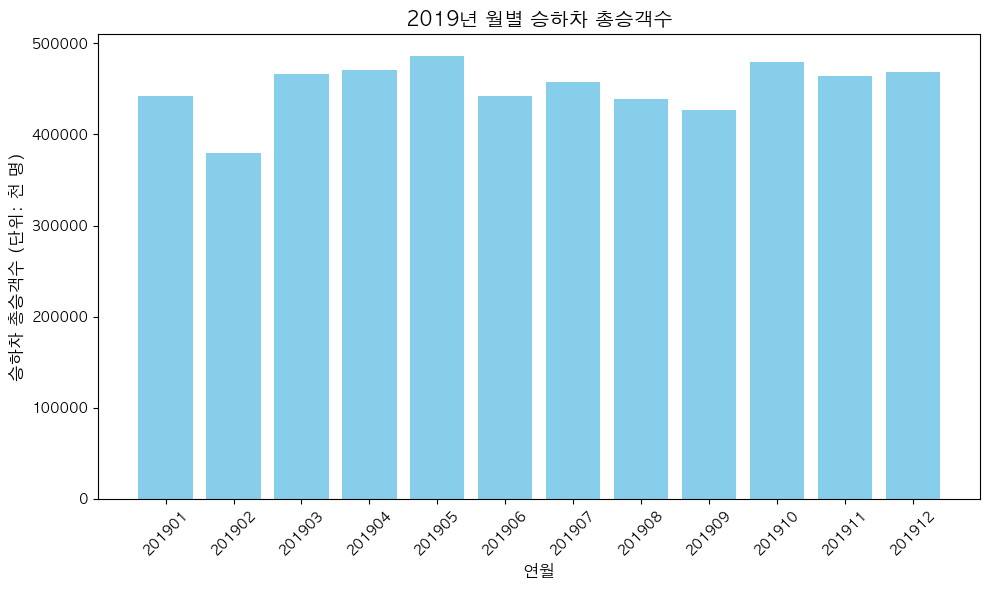

In [269]:
#맥북 한글 꺠짐 이슈..
plt.rcParams['font.family'] = 'AppleGothic'

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# barplot 그리기
plt.bar(monthly_2019['연월'], monthly_2019['승하차총승객수'], color='skyblue')

# 그래프 제목과 라벨 설정
plt.title('2019년 월별 승하차 총승객수', fontsize=14)
plt.xlabel('연월', fontsize=12)
plt.ylabel('승하차 총승객수 (단위: 천 명)', fontsize=12)

# x축 라벨 각도 조정
plt.xticks(rotation=45)

# 그래프 출력
plt.tight_layout()
plt.show()


#### 2018, 2020년과 비교

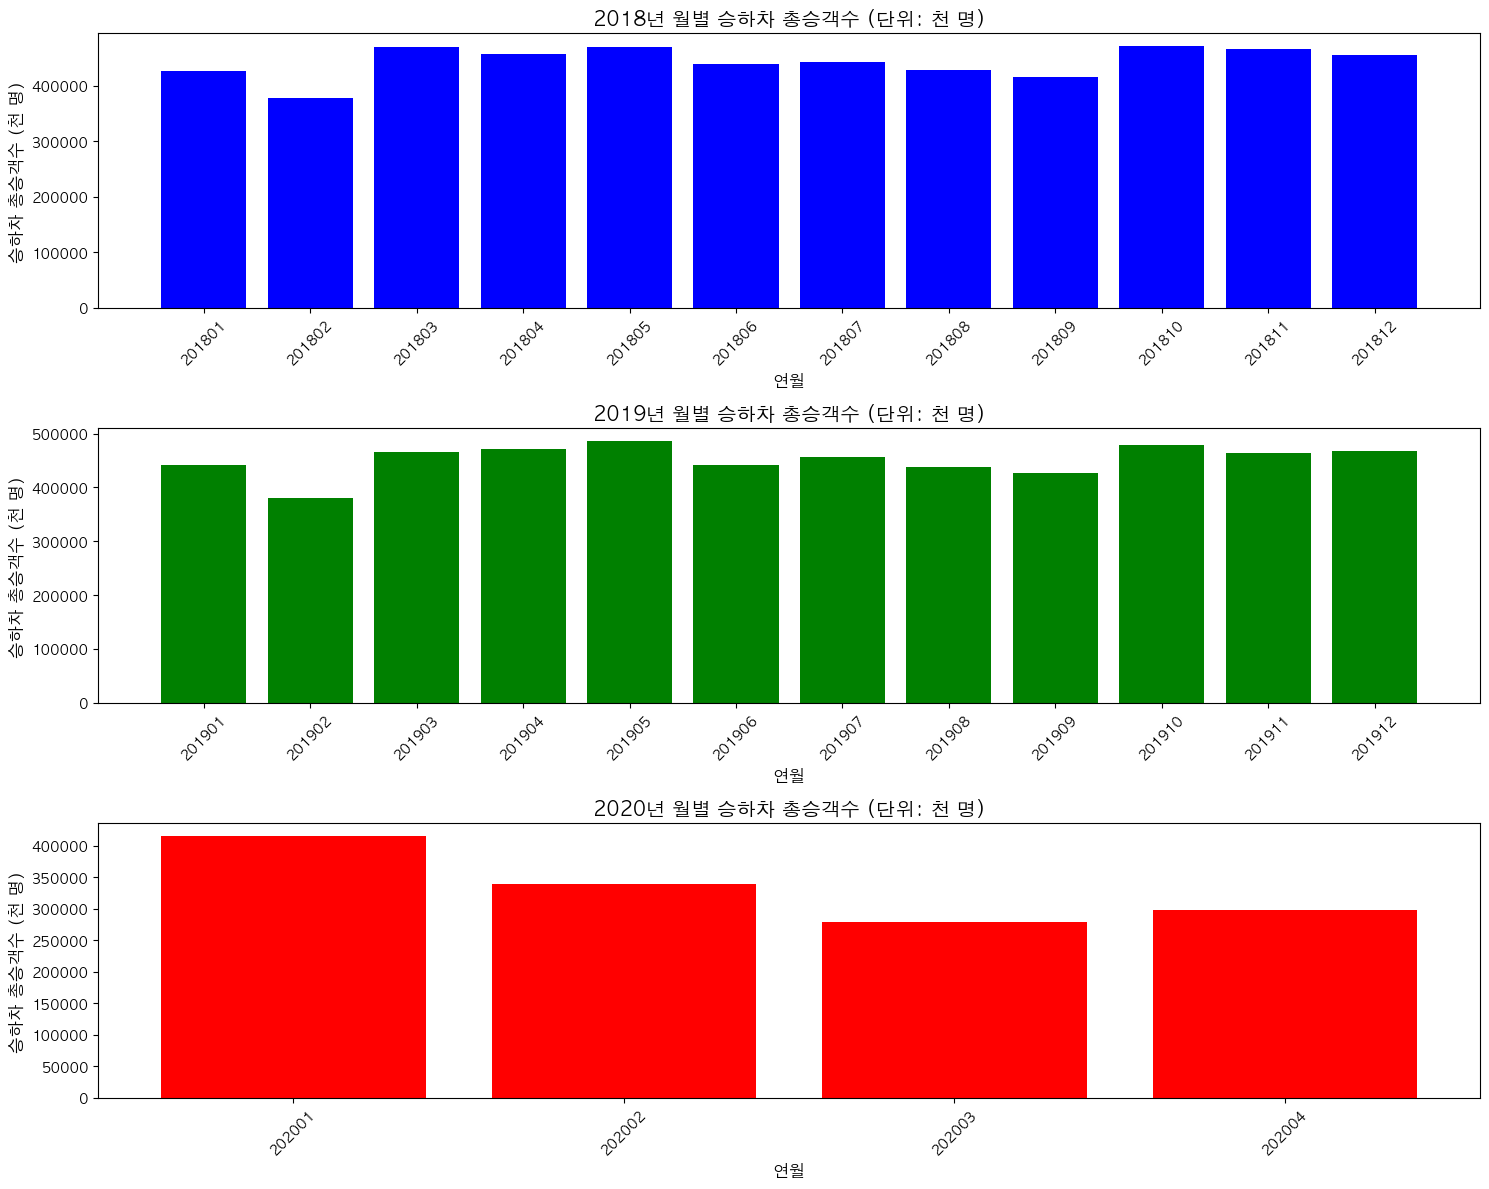

In [271]:
# '연월'과 '승하차총승객수' 컬럼 생성
raw['연월'] = raw['사용일자'].astype(str).str[:6]  # '사용일자'에서 연월(YYYYMM) 추출
raw['승하차총승객수'] = raw['승차총승객수'] + raw['하차총승객수']  # 승하차 합계

# 각 연도별 데이터 필터링
data_2018 = raw[raw['연월'].str.startswith('2018')]
data_2019 = raw[raw['연월'].str.startswith('2019')]
data_2020 = raw[raw['연월'].str.startswith('2020')]

# 월별 승하차 총승객수 집계
monthly_2018 = data_2018.groupby('연월').agg({'승하차총승객수': 'sum'}).reset_index()
monthly_2019 = data_2019.groupby('연월').agg({'승하차총승객수': 'sum'}).reset_index()
monthly_2020 = data_2020.groupby('연월').agg({'승하차총승객수': 'sum'}).reset_index()

# 승하차 총승객수를 천 명 단위로 나누기
monthly_2018['승하차총승객수'] = monthly_2018['승하차총승객수'] / 1000
monthly_2019['승하차총승객수'] = monthly_2019['승하차총승객수'] / 1000
monthly_2020['승하차총승객수'] = monthly_2020['승하차총승객수'] / 1000

# 그래프 크기 설정
plt.figure(figsize=(15, 12))

# 1. 2018년 월별 승하차 총승객수
plt.subplot(3, 1, 1)
plt.bar(monthly_2018['연월'], monthly_2018['승하차총승객수'], color='blue')
plt.title('2018년 월별 승하차 총승객수 (단위: 천 명)', fontsize=14)
plt.xlabel('연월', fontsize=12)
plt.ylabel('승하차 총승객수 (천 명)', fontsize=12)
plt.xticks(rotation=45)

# 2. 2019년 월별 승하차 총승객수
plt.subplot(3, 1, 2)
plt.bar(monthly_2019['연월'], monthly_2019['승하차총승객수'], color='green')
plt.title('2019년 월별 승하차 총승객수 (단위: 천 명)', fontsize=14)
plt.xlabel('연월', fontsize=12)
plt.ylabel('승하차 총승객수 (천 명)', fontsize=12)
plt.xticks(rotation=45)

# 3. 2020년 월별 승하차 총승객수
plt.subplot(3, 1, 3)
plt.bar(monthly_2020['연월'], monthly_2020['승하차총승객수'], color='red')
plt.title('2020년 월별 승하차 총승객수 (단위: 천 명)', fontsize=14)
plt.xlabel('연월', fontsize=12)
plt.ylabel('승하차 총승객수 (천 명)', fontsize=12)
plt.xticks(rotation=45)

# 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()


In [272]:
# 2020년 각 월별 데이터 개수 확인
monthly_count_2020 = raw[raw['연월'].str.startswith('2020')].groupby('연월').size()
print("2020년 각 월별 데이터 개수:")
print(monthly_count_2020)

2020년 각 월별 데이터 개수:
연월
202001    18312
202002    17118
202003    18265
202004    17722
dtype: int64


In [273]:
import pandas as pd

# CSV 파일 경로
sub_file3 = r'./subway_data/CARD_SUBWAY_MONTH_2020.csv'

# CSV 파일 읽기
data_2020 = pd.read_csv(sub_file3, encoding='euc-kr',on_bad_lines='skip')

data_2020['사용일자'] = data_2020['사용일자'].astype(str)

# 12월 데이터 확인
december_data = data_2020[data_2020['사용일자'].str.startswith('202012')]
print("2020년 12월 데이터:")
print(december_data)


2020년 12월 데이터:
Empty DataFrame
Columns: [사용일자, 노선명, 역명, 승차총승객수, 하차총승객수, 등록일자]
Index: []


## 가설2 추가조사 - 2호선의 승하차총승객수가 가장 많다

In [43]:
# 6개의 파일을 불러와서 합침
file1 = r'./rawfiles/CARD_SUBWAY_MONTH_201901.csv'
file2 = r'./rawfiles/CARD_SUBWAY_MONTH_201902.csv'
file3 = r'./rawfiles/CARD_SUBWAY_MONTH_201903.csv'
file4 = r'./rawfiles/CARD_SUBWAY_MONTH_201904.csv'
file5 = r'./rawfiles/CARD_SUBWAY_MONTH_201905.csv'
file6 = r'./rawfiles/CARD_SUBWAY_MONTH_201906.csv'

# 파일을 읽어들이기
temp1 = pd.read_csv(file1)
temp2 = pd.read_csv(file2)
temp3 = pd.read_csv(file3)
temp4 = pd.read_csv(file4)
temp5 = pd.read_csv(file5)
temp6 = pd.read_csv(file6)

# 6개의 파일을 합침
raw_6months = pd.concat([temp1, temp2, temp3, temp4, temp5, temp6], axis=0, ignore_index=True)

# 승차총승객수와 하차총승객수를 더해서 승하차총승객수 열을 생성
raw_6months['승하차총승객수'] = raw_6months['승차총승객수'] + raw_6months['하차총승객수']

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_6months = raw_6months.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 결과 출력
print(line_usage_6months)


        노선명      승하차총승객수
0       1호선  442595645.0
1       2호선  620950820.0
2       3호선  296507251.0
3       4호선  336819726.0
4       5호선  213739705.0
5       6호선  100925682.0
6       7호선  205199875.0
7       8호선   49393731.0
8       9호선   84803325.0
9       경강선    7965355.0
10      경의선  127579565.0
11      경춘선   14028191.0
12     공항철도   14395020.0
13      분당선  135962111.0
14      수인선   16159276.0
15     신분당선    1413470.0
16  우이신설경전철   12938033.0
17    인천2호선    2922652.0
18      인천선    3839332.0


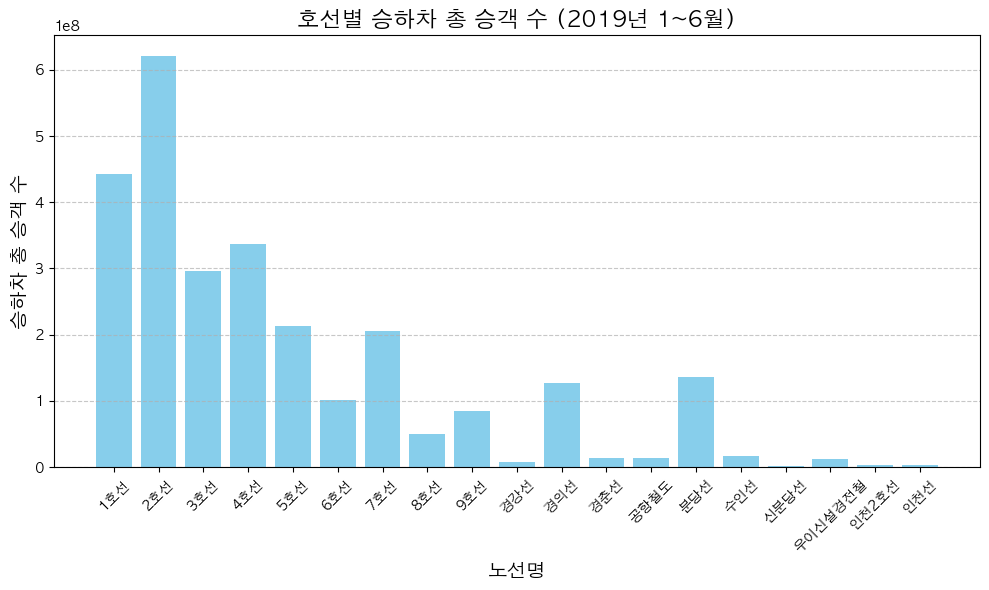

In [45]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'

# 호선별 승하차 총 승객수 시각화
plt.figure(figsize=(10, 6))
plt.bar(line_usage_6months['노선명'], line_usage_6months['승하차총승객수'], color='skyblue')
plt.title('호선별 승하차 총 승객 수 (2019년 1~6월)', fontsize=16)
plt.xlabel('노선명', fontsize=14)
plt.ylabel('승하차 총 승객 수', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 보여주기
plt.show()

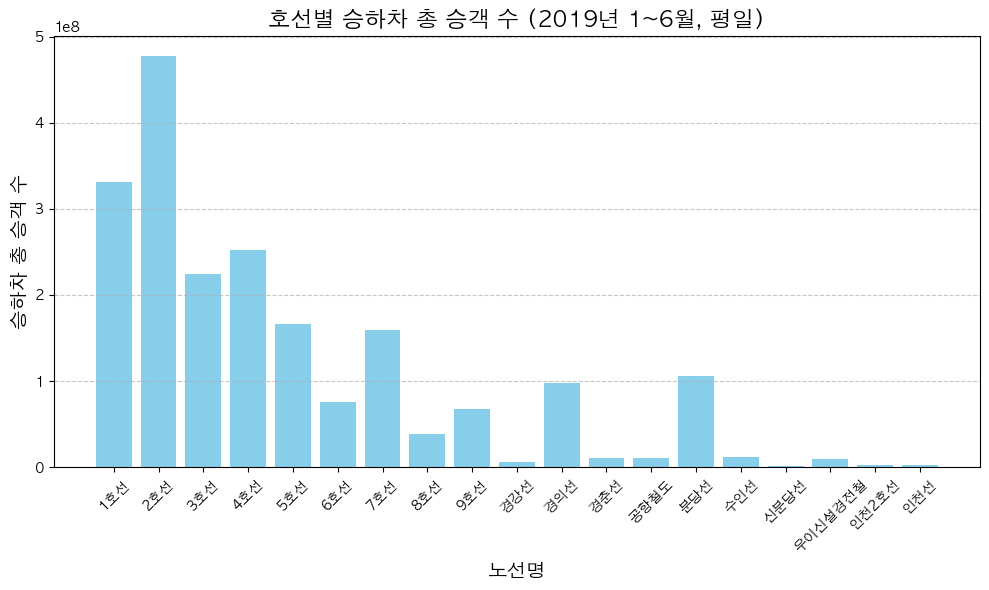

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# 승차총승객수와 하차총승객수를 더해서 승하차총승객수 열을 생성
raw_6months['승하차총승객수'] = raw_6months['승차총승객수'] + raw_6months['하차총승객수']

# '사용일자'를 datetime 형식으로 변환
raw_6months['사용일자'] = pd.to_datetime(raw_6months['사용일자'], format='%Y%m%d')

# 공휴일 목록
holidays = [
    '2019-01-01',  # 신정
    '2019-02-04', '2019-02-05', '2019-02-06',  # 설연휴
    '2019-03-01',  # 삼일절
    '2019-05-05',  # 어린이날
    '2019-05-12',  # 부처님오신날
    '2019-06-06'   # 현충일
]

# 공휴일을 datetime 형식으로 변환
holidays = pd.to_datetime(holidays)

# 평일 데이터 필터링 (공휴일 제외)
weekdays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek < 5) &  # 월요일~금요일
    (~raw_6months['사용일자'].isin(holidays))  # 공휴일 제외
]

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_weekdays = weekdays.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 그래프 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.figure(figsize=(10, 6))

# 호선별 승하차 총 승객수 시각화
plt.bar(line_usage_weekdays['노선명'], line_usage_weekdays['승하차총승객수'], color='skyblue')
plt.title('호선별 승하차 총 승객 수 (2019년 1~6월, 평일)', fontsize=16)
plt.xlabel('노선명', fontsize=14)
plt.ylabel('승하차 총 승객 수', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 보여주기
plt.show()

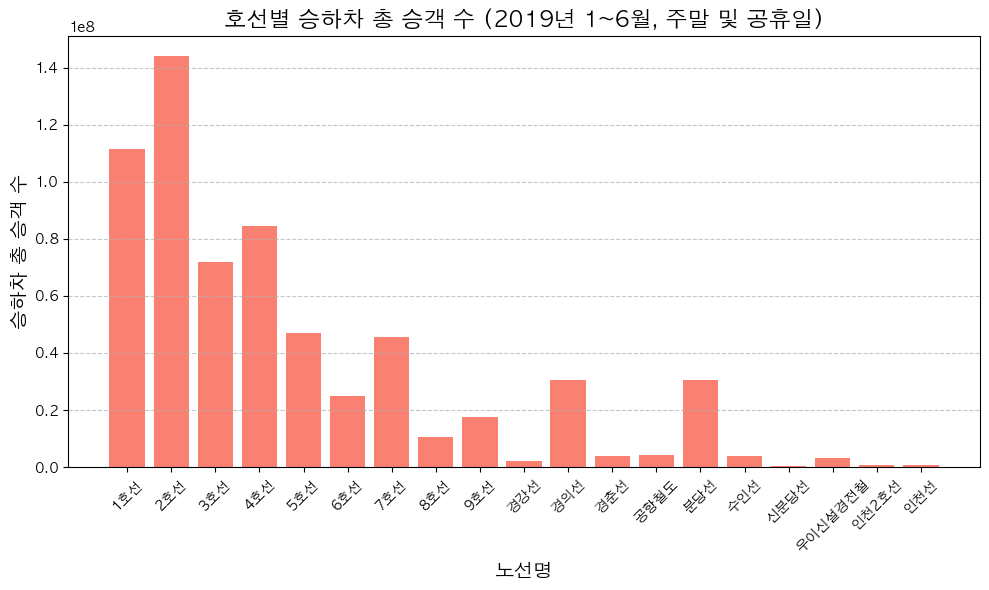

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 6개월 데이터 파일 읽어오기
file1 = r'./rawfiles/CARD_SUBWAY_MONTH_201901.csv'
file2 = r'./rawfiles/CARD_SUBWAY_MONTH_201902.csv'
file3 = r'./rawfiles/CARD_SUBWAY_MONTH_201903.csv'
file4 = r'./rawfiles/CARD_SUBWAY_MONTH_201904.csv'
file5 = r'./rawfiles/CARD_SUBWAY_MONTH_201905.csv'
file6 = r'./rawfiles/CARD_SUBWAY_MONTH_201906.csv'

# 파일을 읽어들이기
temp1 = pd.read_csv(file1)
temp2 = pd.read_csv(file2)
temp3 = pd.read_csv(file3)
temp4 = pd.read_csv(file4)
temp5 = pd.read_csv(file5)
temp6 = pd.read_csv(file6)

# 6개의 파일을 합침
raw_6months = pd.concat([temp1, temp2, temp3, temp4, temp5, temp6], axis=0, ignore_index=True)

# 승차총승객수와 하차총승객수를 더해서 승하차총승객수 열을 생성
raw_6months['승하차총승객수'] = raw_6months['승차총승객수'] + raw_6months['하차총승객수']

# '사용일자'를 datetime 형식으로 변환
raw_6months['사용일자'] = pd.to_datetime(raw_6months['사용일자'], format='%Y%m%d')

# 공휴일 목록
holidays = [
    '2019-01-01',  # 신정
    '2019-02-04', '2019-02-05', '2019-02-06',  # 설연휴
    '2019-03-01',  # 삼일절
    '2019-05-05',  # 어린이날
    '2019-05-12',  # 부처님오신날
    '2019-06-06'   # 현충일
]

# 공휴일을 datetime 형식으로 변환
holidays = pd.to_datetime(holidays)

# 주말 및 공휴일 데이터 필터링
weekend_holidays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek >= 5) |  # 주말: 토요일(5), 일요일(6)
    (raw_6months['사용일자'].isin(holidays))      # 공휴일
]

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_weekend_holidays = weekend_holidays.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 그래프 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.figure(figsize=(10, 6))

# 호선별 승하차 총 승객수 시각화
plt.bar(line_usage_weekend_holidays['노선명'], line_usage_weekend_holidays['승하차총승객수'], color='salmon')
plt.title('호선별 승하차 총 승객 수 (2019년 1~6월, 주말 및 공휴일)', fontsize=16)
plt.xlabel('노선명', fontsize=14)
plt.ylabel('승하차 총 승객 수', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 보여주기
plt.show()


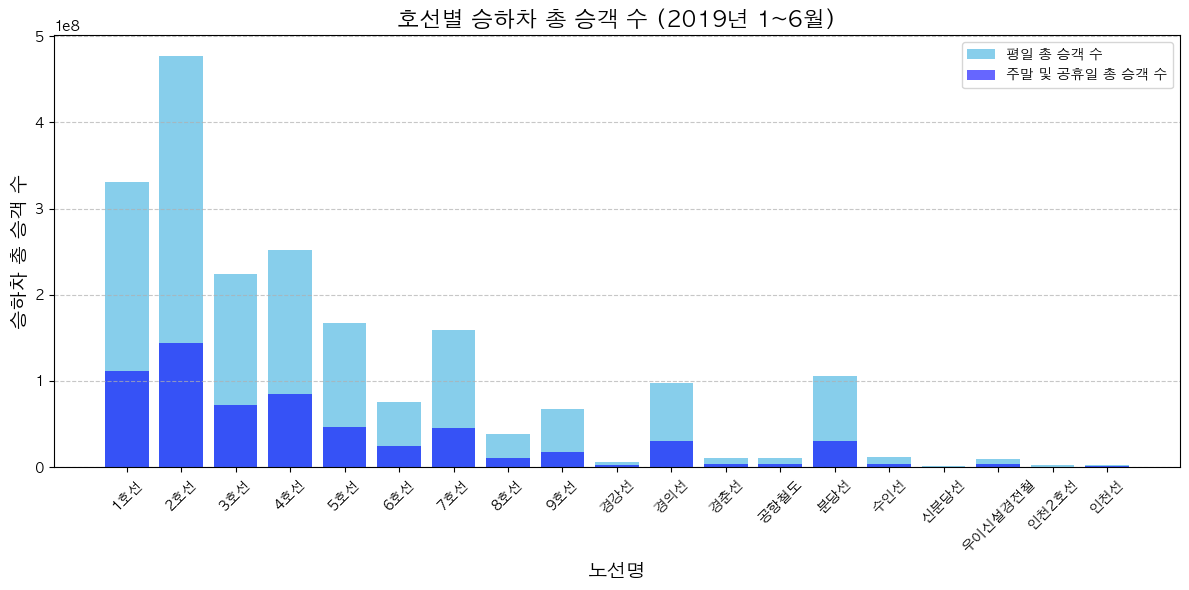

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# 평일 데이터 필터링 (공휴일 제외)
weekdays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek < 5) &  # 월요일~금요일
    (~raw_6months['사용일자'].isin(holidays))  # 공휴일 제외
]

# 주말 및 공휴일 데이터 필터링
weekend_holidays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek >= 5) |  # 주말: 토요일(5), 일요일(6)
    (raw_6months['사용일자'].isin(holidays))      # 공휴일
]

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_weekdays = weekdays.groupby('노선명')['승하차총승객수'].sum().reset_index()
line_usage_weekend_holidays = weekend_holidays.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 그래프 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.figure(figsize=(12, 6))

# 호선별 승하차 총 승객수 시각화
plt.bar(line_usage_weekdays['노선명'], line_usage_weekdays['승하차총승객수'], color='skyblue', label='평일 총 승객 수')
plt.bar(line_usage_weekend_holidays['노선명'], line_usage_weekend_holidays['승하차총승객수'], color='blue', label='주말 및 공휴일 총 승객 수', alpha=0.6)

plt.title('호선별 승하차 총 승객 수 (2019년 1~6월)', fontsize=16)
plt.xlabel('노선명', fontsize=14)
plt.ylabel('승하차 총 승객 수', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# 그래프 보여주기
plt.tight_layout()
plt.show()


In [57]:
import pandas as pd

# 공휴일 목록
holidays = [
    '2019-01-01',  # 신정
    '2019-02-04', '2019-02-05', '2019-02-06',  # 설연휴
    '2019-03-01',  # 삼일절
    '2019-05-05',  # 어린이날
    '2019-05-12',  # 부처님오신날
    '2019-06-06'   # 현충일
]

# 공휴일을 datetime 형식으로 변환
holidays = pd.to_datetime(holidays)

# 평일 데이터 필터링 (공휴일 제외)
weekdays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek < 5) &  # 월요일~금요일
    (~raw_6months['사용일자'].isin(holidays))  # 공휴일 제외
]

# 주말 및 공휴일 데이터 필터링
weekend_holidays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek >= 5) |  # 주말: 토요일(5), 일요일(6)
    (raw_6months['사용일자'].isin(holidays))      # 공휴일
]

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_weekdays = weekdays.groupby('노선명')['승하차총승객수'].sum().reset_index()
line_usage_weekend_holidays = weekend_holidays.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 두 데이터프레임을 병합
comparison = pd.merge(line_usage_weekdays, line_usage_weekend_holidays, on='노선명', suffixes=('_평일', '_주말'))

# 퍼센트 감소 계산
comparison['퍼센트 감소'] = ((comparison['승하차총승객수_평일'] - comparison['승하차총승객수_주말']) / comparison['승하차총승객수_평일']) * 100

# 결과 출력
print(comparison[['노선명', '승하차총승객수_평일', '승하차총승객수_주말', '퍼센트 감소']])


        노선명   승하차총승객수_평일   승하차총승객수_주말     퍼센트 감소
0       1호선  331191807.0  111403838.0  66.362743
1       2호선  477028017.0  143922803.0  69.829277
2       3호선  224575076.0   71932175.0  67.969653
3       4호선  252355065.0   84464661.0  66.529437
4       5호선  166712028.0   47027677.0  71.791071
5       6호선   75925334.0   25000348.0  67.072456
6       7호선  159578686.0   45621189.0  71.411477
7       8호선   38785915.0   10607816.0  72.650340
8       9호선   67102678.0   17700647.0  73.621549
9       경강선    5932050.0    2033305.0  65.723401
10      경의선   97173766.0   30405799.0  68.709869
11      경춘선   10180811.0    3847380.0  62.209494
12     공항철도   10226082.0    4168938.0  59.232304
13      분당선  105567337.0   30394774.0  71.208165
14      수인선   12221587.0    3937689.0  67.780870
15     신분당선    1123942.0     289528.0  74.239952
16  우이신설경전철    9769095.0    3168938.0  67.561601
17    인천2호선    2233774.0     688878.0  69.160801
18      인천선    2966211.0     873121.0  70.564434


In [59]:
import pandas as pd

# 6개의 파일을 합침
raw_6months = pd.concat([temp1, temp2, temp3, temp4, temp5, temp6], axis=0, ignore_index=True)

# 승차총승객수와 하차총승객수를 더해서 승하차총승객수 열을 생성
raw_6months['승하차총승객수'] = raw_6months['승차총승객수'] + raw_6months['하차총승객수']

# '사용일자'를 datetime 형식으로 변환
raw_6months['사용일자'] = pd.to_datetime(raw_6months['사용일자'], format='%Y%m%d')

# 공휴일 목록
holidays = [
    '2019-01-01',  # 신정
    '2019-02-04', '2019-02-05', '2019-02-06',  # 설연휴
    '2019-03-01',  # 삼일절
    '2019-05-05',  # 어린이날
    '2019-05-12',  # 부처님오신날
    '2019-06-06'   # 현충일
]

# 공휴일을 datetime 형식으로 변환
holidays = pd.to_datetime(holidays)

# 평일 데이터 필터링 (공휴일 제외)
weekdays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek < 5) &  # 월요일~금요일
    (~raw_6months['사용일자'].isin(holidays))  # 공휴일 제외
]

# 주말 및 공휴일 데이터 필터링
weekend_holidays = raw_6months[
    (raw_6months['사용일자'].dt.dayofweek >= 5) |  # 주말: 토요일(5), 일요일(6)
    (raw_6months['사용일자'].isin(holidays))      # 공휴일
]

# 노선별로 승하차 총 승객수를 그룹화하여 합계 계산
line_usage_weekdays = weekdays.groupby('노선명')['승하차총승객수'].sum().reset_index()
line_usage_weekend_holidays = weekend_holidays.groupby('노선명')['승하차총승객수'].sum().reset_index()

# 두 데이터프레임을 병합
comparison = pd.merge(line_usage_weekdays, line_usage_weekend_holidays, on='노선명', suffixes=('_평일', '_주말'))

# 퍼센트 감소 계산
comparison['퍼센트 감소'] = ((comparison['승하차총승객수_평일'] - comparison['승하차총승객수_주말']) / comparison['승하차총승객수_평일']) * 100

# 퍼센트 감소 기준으로 내림차순 정렬
comparison_sorted = comparison.sort_values(by='퍼센트 감소', ascending=False)

# 결과 출력
print(comparison_sorted[['노선명', '승하차총승객수_평일', '승하차총승객수_주말', '퍼센트 감소']])

        노선명   승하차총승객수_평일   승하차총승객수_주말     퍼센트 감소
15     신분당선    1123942.0     289528.0  74.239952
8       9호선   67102678.0   17700647.0  73.621549
7       8호선   38785915.0   10607816.0  72.650340
4       5호선  166712028.0   47027677.0  71.791071
6       7호선  159578686.0   45621189.0  71.411477
13      분당선  105567337.0   30394774.0  71.208165
18      인천선    2966211.0     873121.0  70.564434
1       2호선  477028017.0  143922803.0  69.829277
17    인천2호선    2233774.0     688878.0  69.160801
10      경의선   97173766.0   30405799.0  68.709869
2       3호선  224575076.0   71932175.0  67.969653
14      수인선   12221587.0    3937689.0  67.780870
16  우이신설경전철    9769095.0    3168938.0  67.561601
5       6호선   75925334.0   25000348.0  67.072456
3       4호선  252355065.0   84464661.0  66.529437
0       1호선  331191807.0  111403838.0  66.362743
9       경강선    5932050.0    2033305.0  65.723401
11      경춘선   10180811.0    3847380.0  62.209494
12     공항철도   10226082.0    4168938.0  59.232304


In [63]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 725.8 kB/s eta 0:00:0000:0100:02
Note: you may need to restart the kernel to use updated packages.


In [67]:
print(line2_decrease)

1    69.829277
Name: 퍼센트 감소, dtype: float64


In [69]:
# 다른 노선들의 퍼센트 감소 평균 계산
other_lines_mean_decrease = comparison[comparison['노선명'] != '2호선']['퍼센트 감소'].mean()

# 2호선의 퍼센트 감소와 비교
line2_decrease = comparison[comparison['노선명'] == '2호선']['퍼센트 감소'].values[0]

# 결과 출력
print(f"다른 노선들의 평균 퍼센트 감소: {other_lines_mean_decrease:.2f}%")
print(f"2호선 퍼센트 감소: {line2_decrease:.2f}%")

if line2_decrease < other_lines_mean_decrease:
    print(f"2호선의 퍼센트 감소가 평균보다 {other_lines_mean_decrease - line2_decrease:.2f}% 더 적습니다.")
else:
    print("2호선의 퍼센트 감소가 평균보다 많거나 같습니다.")

다른 노선들의 평균 퍼센트 감소: 68.54%
2호선 퍼센트 감소: 69.83%
2호선의 퍼센트 감소가 평균보다 많거나 같습니다.


In [65]:
from scipy import stats

# 2호선의 퍼센트 감소 추출
line2_decrease = comparison[comparison['노선명'] == '2호선']['퍼센트 감소']

# 2호선을 제외한 다른 노선들의 퍼센트 감소 추출
other_lines_decrease = comparison[comparison['노선명'] != '2호선']['퍼센트 감소']

# t-검정 수행 (양측 검정)
t_stat, p_value = stats.ttest_ind(other_lines_decrease, line2_decrease, equal_var=False)

# 결과 출력
print(f"t-통계량: {t_stat}")
print(f"p-값: {p_value}")

t-통계량: nan
p-값: nan


/Users/yuserih/env39/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/yuserih/env39/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [25]:
import pandas as pd

# 6개월 데이터에서 2호선에 해당하는 역 데이터 필터링
line2_data = raw_6months[raw_6months['노선명'] == '2호선']

# 승하차 총 승객 수를 계산하여 역별로 그룹화
boarding_usage_line2 = line2_data.groupby('역명')['승하차총승객수'].sum().reset_index()

# 승하차 총 승객 수가 가장 많은 역 순으로 정렬 후 상위 5개 선택
top5_stations_line2 = boarding_usage_line2.sort_values(by='승하차총승객수', ascending=False).head(5)

# 순위 매기기 및 출력
for i, row in enumerate(top5_stations_line2.itertuples(index=False), start=1):
    print(f"{i}. {row.역명} - 승하차 총 승객 수: {row.승하차총승객수:.0f}명")

1. 잠실 - 승하차 총 승객 수: 36964397명
2. 강남 - 승하차 총 승객 수: 36618233명
3. 홍대입구 - 승하차 총 승객 수: 35593444명
4. 사당 - 승하차 총 승객 수: 26720074명
5. 신림 - 승하차 총 승객 수: 25352732명


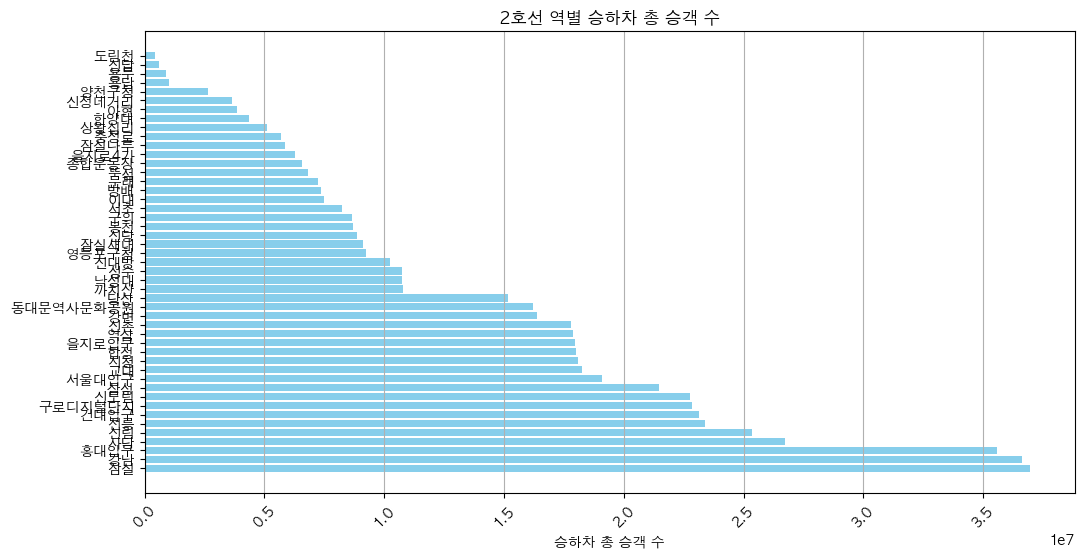

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 6개월 데이터에서 2호선에 해당하는 역 데이터 필터링
line2_data = raw_6months[raw_6months['노선명'] == '2호선']

# 승하차 총 승객 수를 계산하여 역별로 그룹화
boarding_usage_line2 = line2_data.groupby('역명')['승하차총승객수'].sum().reset_index()

# 승하차 총 승객 수가 가장 많은 역 순으로 정렬
sorted_stations = boarding_usage_line2.sort_values(by='승하차총승객수', ascending=False)

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.barh(sorted_stations['역명'], sorted_stations['승하차총승객수'], color='skyblue')
plt.xlabel('승하차 총 승객 수')
plt.title('2호선 역별 승하차 총 승객 수')
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.show()

In [29]:
import pandas as pd
import folium

# 6개월 데이터에서 2호선에 해당하는 역 이름 추출
line2_stations = raw_6months[raw_6months['노선명'] == '2호선']['역명'].unique().tolist()

# 위경도 데이터 불러오기
coords_file = './rawfiles/지하철노선위경도정보2.csv'
coords_data = pd.read_csv(coords_file)

# 2호선 역의 위경도 정보 가져오기
line2_coords = coords_data[coords_data['역이름'].isin(line2_stations)]

# 지도 생성 (서울 중심부로 지정)
seoul_map = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 최소 및 최대 승객수를 계산하여 색상 스케일을 지정
min_passengers = raw_6months['승차총승객수'].min()
max_passengers = raw_6months['승차총승객수'].max()

# 2호선 경로를 저장할 리스트
line2_path = []

# 2호선 데이터와 위경도 정보를 연결하여 마커 추가
for station in line2_stations:
    # 위경도 데이터에서 해당 역의 좌표를 찾음
    station_info = line2_coords[line2_coords['역이름'] == station]
    
    if not station_info.empty:
        lat = station_info['위도'].values[0]
        lon = station_info['경도'].values[0]
        
        # 해당 역의 승차 총 승객 수 가져오기
        passengers = raw_6months[raw_6months['역명'] == station]['승차총승객수'].sum()
        
        # 색상 설정 (승객 수가 많을수록 빨간색, 적을수록 초록색)
        color = folium.LinearColormap(['green', 'yellow', 'red'], vmin=min_passengers, vmax=max_passengers)(passengers)
        
        # 마커 추가
        folium.CircleMarker(
            location=[lat, lon],
            radius=7,  # 원의 크기
            color=color,  # 테두리 색상
            fill=True,
            fill_color=color,  # 채우기 색상
            fill_opacity=0.7,
            popup=(f"{station}: {passengers}명")
        ).add_to(seoul_map)
        
        # 경로에 좌표 추가
        line2_path.append([lat, lon])

# 2호선 경로 시각화 (PolyLine으로 선 연결)
folium.PolyLine(
    line2_path,
    color='blue',  # 경로 선 색상
    weight=3,  # 선 두께
    opacity=0.7  # 투명도
).add_to(seoul_map)

# 결과 지도 저장 또는 출력
seoul_map.save("line2_map_with_path.html")

# 주피터 노트북에서 바로 보려면
seoul_map


In [31]:
import pandas as pd
import folium

# 6개월 데이터에서 2호선에 해당하는 역 이름 추출
line2_stations = raw_6months[raw_6months['노선명'] == '2호선']['역명'].unique().tolist()

# 위경도 데이터 불러오기
coords_file = './rawfiles/지하철노선위경도정보2.csv'
coords_data = pd.read_csv(coords_file)

# 2호선 역의 위경도 정보 가져오기
line2_coords = coords_data[coords_data['역이름'].isin(line2_stations)]

# 지도 생성 (서울 중심부로 지정)
seoul_map = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 최소 및 최대 승객수를 계산하여 색상 스케일을 지정
min_passengers = raw_6months['승차총승객수'].min()
max_passengers = raw_6months['승차총승객수'].max()

# 2호선 경로를 저장할 리스트
line2_path = []

# 2호선 데이터와 위경도 정보를 연결하여 마커 추가
for station in line2_stations:
    # 위경도 데이터에서 해당 역의 좌표를 찾음
    station_info = line2_coords[line2_coords['역이름'] == station]
    
    if not station_info.empty:
        lat = station_info['위도'].values[0]
        lon = station_info['경도'].values[0]
        
        # 해당 역의 승차 총 승객 수 가져오기
        boarding_count = raw_6months[raw_6months['역명'] == station]['승차총승객수'].sum()
        
        # CircleMarker 추가 (파란색으로 설정)
        folium.CircleMarker(
            location=[lat, lon],
            radius=10,  # 원의 반지름
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"<strong>{station}</strong><br>승차 인원: <strong>{boarding_count}명</strong>"
        ).add_to(seoul_map)
        
        # 경로에 좌표 추가
        line2_path.append([lat, lon])

# 2호선 경로 시각화 (PolyLine으로 선 연결)
folium.PolyLine(
    line2_path,
    color='blue',  # 경로 선 색상
    weight=3,  # 선 두께
    opacity=0.7  # 투명도
).add_to(seoul_map)

# 결과 지도 저장 또는 출력
seoul_map.save("line2_map_with_path.html")

# 주피터 노트북에서 바로 보려면
seoul_map


In [33]:
import pandas as pd
import folium

# 6개월 데이터에서 2호선에 해당하는 역 이름 추출
line2_stations = raw_6months[raw_6months['노선명'] == '2호선']['역명'].unique().tolist()

# 위경도 데이터 불러오기
coords_file = './rawfiles/지하철노선위경도정보2.csv'
coords_data = pd.read_csv(coords_file)

# 2호선 역의 위경도 정보 가져오기
line2_coords = coords_data[coords_data['역이름'].isin(line2_stations)]

# 지도 생성 (서울 중심부로 지정)
seoul_map = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 최소 및 최대 승객수를 계산하여 색상 스케일을 지정
min_passengers = raw_6months['승차총승객수'].min()
max_passengers = raw_6months['승차총승객수'].max()

# 2호선 경로를 저장할 리스트
line2_path = []

# 2호선 데이터와 위경도 정보를 연결하여 마커 추가
for station in line2_stations:
    # 위경도 데이터에서 해당 역의 좌표를 찾음
    station_info = line2_coords[line2_coords['역이름'] == station]
    
    if not station_info.empty:
        lat = station_info['위도'].values[0]
        lon = station_info['경도'].values[0]
        
        # 해당 역의 승차 총 승객 수 가져오기
        boarding_count = raw_6months[raw_6months['역명'] == station]['승차총승객수'].sum()
        
        # CircleMarker 추가 (파란색으로 설정, 승차 인원에 따라 크기 조정)
        circle_radius = min(max(10, boarding_count / 100), 30)  # 승차 인원에 따라 반지름 조정
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=circle_radius,  # 승차 인원에 따라 반지름 조정
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"<strong>{station}</strong><br>승차 인원: <strong>{boarding_count}명</strong>"
        ).add_to(seoul_map)

        # 빨간색 마커 추가
        folium.Marker(
            location=[lat, lon],
            popup=f"<strong>{station}</strong><br>승차 인원: <strong>{boarding_count}명</strong>",
            icon=folium.Icon(color='red', icon='info-sign', prefix='glyphicon')  # 빨간색 아이콘
        ).add_to(seoul_map)

        # 경로에 좌표 추가
        line2_path.append([lat, lon])

# 2호선 경로 시각화 (PolyLine으로 선 연결)
folium.PolyLine(
    line2_path,
    color='blue',  # 경로 선 색상
    weight=3,  # 선 두께
    opacity=0.7  # 투명도
).add_to(seoul_map)

# 결과 지도 저장 또는 출력
seoul_map.save("line2_map_with_path.html")

# 주피터 노트북에서 바로 보려면
seoul_map
